# 00 · Quick start

`foresight_gpu` turns a deterministic model into a **reliable probabilistic forecast** using the Generalized Pareto Uncertainty (GPU) method. The public interface is a scikit-learn regressor.

- `predict(X)` → point estimate (median band)
- `predict_quantiles(X)` → probabilistic bands

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from foresight_gpu import GPURegressor
from foresight_gpu.utils import plot_timeseries, plot_qq
from foresight_gpu.metrics.probabilistic import reliability

### A heteroscedastic toy problem

In [2]:
rng = np.random.default_rng(0)
n = 600
x = np.linspace(0, 1, n)
signal = np.sin(2 * np.pi * x)
noise = (0.2 + 0.6 * x) * rng.standard_normal(n)  # spread grows with x
X = x[:, None]
y = signal + noise

### Fit and predict

In [5]:
gpu = GPURegressor(metric='mae', population=400, n_iter=80, random_state=0)
gpu.fit(X, y)
point = gpu.predict(X)
bands = gpu.predict_quantiles(X)
print('reliability alpha =', round(reliability(gpu.predictive_pvalues(X, y)), 3))

reliability alpha = 0.99


### Visualise the predictive bands

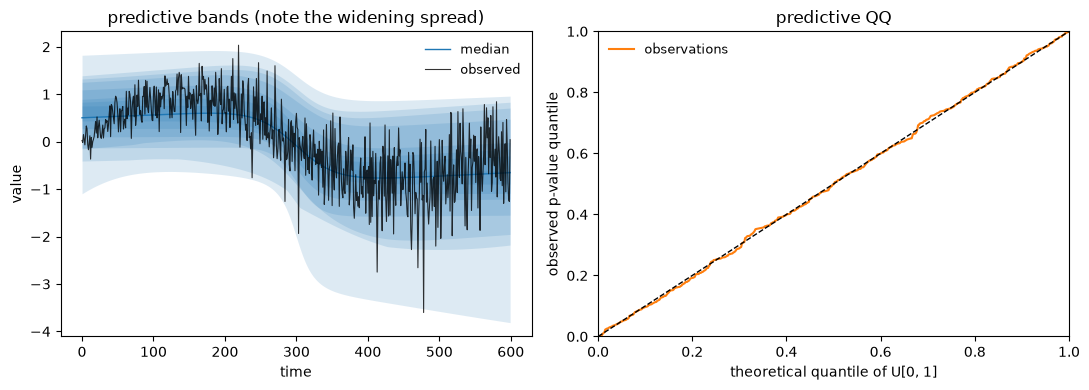

In [ ]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
plot_timeseries(bands, gpu.ensemble_.quantiles, observed=y, ax=a0)
a0.set_title('predictive bands (note the widening spread)')
plot_qq(gpu.predictive_pvalues(X, y), ax=a1)
a1.set_title('predictive QQ')
fig.tight_layout()

The bands widen with `x`, matching the heteroscedastic noise — GPU adapts the distribution shape without being told to. Next: a real seasonal forecast (`01_seasonal_forecast`), a custom model (`02_custom_model`), and diagnostics / model selection (`03_diagnostics`).